## Import libraries

In [30]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from utils.logs_parser import LogsParser

## Parse Logs

In [31]:
parser = LogsParser()

In [32]:
base_path = Path.cwd().parent 

file_path_1a = base_path / "logs" / "log1a.txt"
file_path_1b = base_path / "logs" / "log1b.txt"
file_path_1c = base_path / "logs" / "log1c.txt"
file_path_1d = base_path / "logs" / "log1d.txt"

In [33]:
metrics = ["epoch", "train_loss", "test_loss", "test_acc1", "test_acc5"]

logs_1a = parser.load_txt_logs(file_path=file_path_1a)
extracted_metrics_1a = parser.extract_metrics(logs_1a, *metrics)


logs_1b = parser.load_txt_logs(file_path=file_path_1b)
extracted_metrics_1b = parser.extract_metrics(logs_1b, *metrics)


logs_1c = parser.load_txt_logs(file_path=file_path_1c)
extracted_metrics_1c = parser.extract_metrics(logs_1c, *metrics)


logs_1d = parser.load_txt_logs(file_path=file_path_1d)
extracted_metrics_1d = parser.extract_metrics(logs_1d, *metrics)

## Visualization and Summarize Results

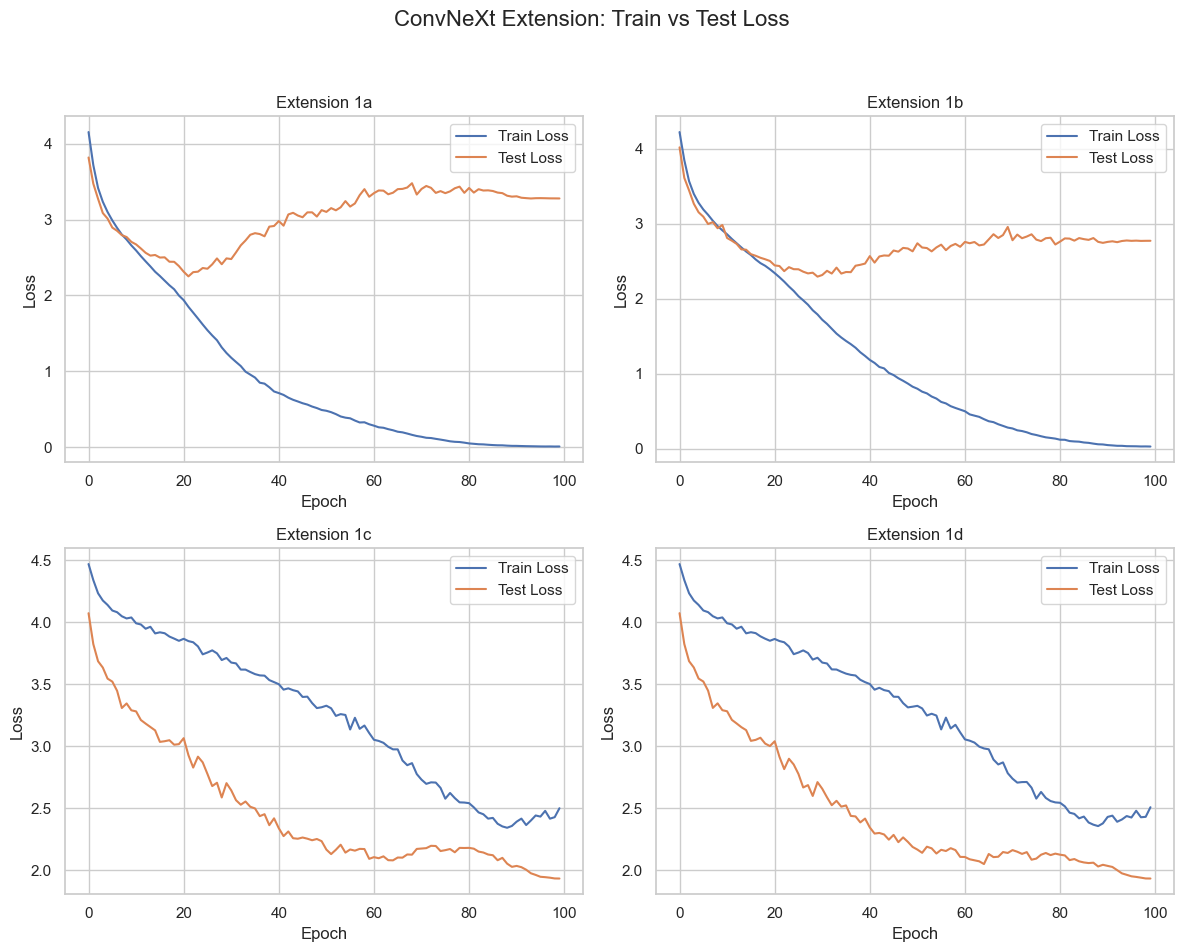

In [34]:
# Initialize Plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('ConvNeXt Extension: Train vs Test Loss', fontsize=16)

# Define the subplots (row, col)
axes[0, 0].plot(extracted_metrics_1a["epoch"], extracted_metrics_1a["train_loss"], label="Train Loss")
axes[0, 0].plot(extracted_metrics_1a["epoch"], extracted_metrics_1a["test_loss"], label="Test Loss")
axes[0, 0].set_title("Extension 1a")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

axes[0, 1].plot(extracted_metrics_1b["epoch"], extracted_metrics_1b["train_loss"], label="Train Loss")
axes[0, 1].plot(extracted_metrics_1b["epoch"], extracted_metrics_1b["test_loss"], label="Test Loss")
axes[0, 1].set_title("Extension 1b")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

axes[1, 0].plot(extracted_metrics_1c["epoch"], extracted_metrics_1c["train_loss"], label="Train Loss")
axes[1, 0].plot(extracted_metrics_1c["epoch"], extracted_metrics_1c["test_loss"], label="Test Loss")
axes[1, 0].set_title("Extension 1c")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()

axes[1, 1].plot(extracted_metrics_1d["epoch"], extracted_metrics_1d["train_loss"], label="Train Loss")
axes[1, 1].plot(extracted_metrics_1d["epoch"], extracted_metrics_1d["test_loss"], label="Test Loss")
axes[1, 1].set_title("Extension 1d")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend()

# Clean up layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

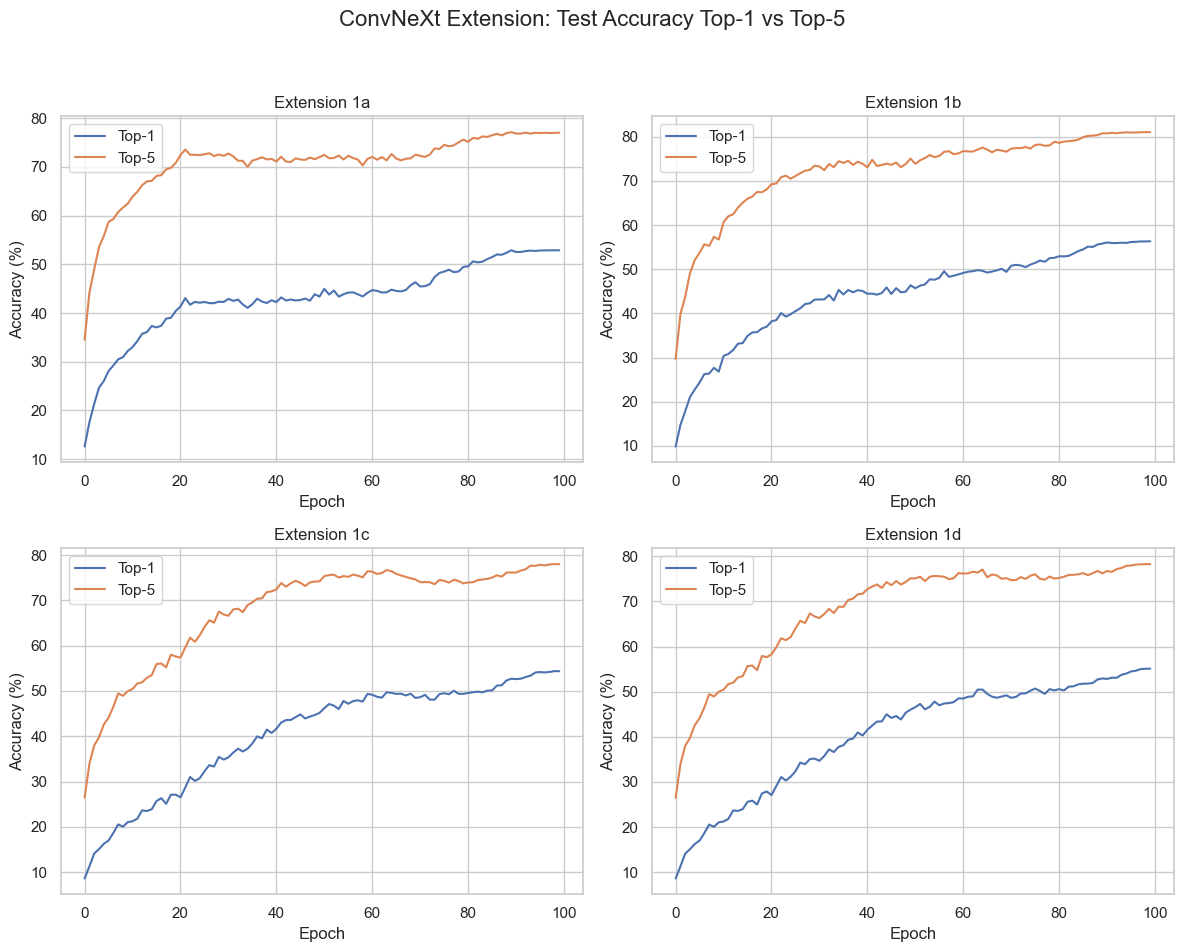

In [35]:
# Initialize Plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('ConvNeXt Extension: Test Accuracy Top-1 vs Top-5', fontsize=16)

# Define the subplots (row, col)
axes[0, 0].plot(extracted_metrics_1a["epoch"], extracted_metrics_1a["test_acc1"], label="Top-1")
axes[0, 0].plot(extracted_metrics_1a["epoch"], extracted_metrics_1a["test_acc5"], label="Top-5")
axes[0, 0].set_title("Extension 1a")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy (%)")
axes[0, 0].legend()

axes[0, 1].plot(extracted_metrics_1b["epoch"], extracted_metrics_1b["test_acc1"], label="Top-1")
axes[0, 1].plot(extracted_metrics_1b["epoch"], extracted_metrics_1b["test_acc5"], label="Top-5")
axes[0, 1].set_title("Extension 1b")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy (%)")
axes[0, 1].legend()

axes[1, 0].plot(extracted_metrics_1c["epoch"], extracted_metrics_1c["test_acc1"], label="Top-1")
axes[1, 0].plot(extracted_metrics_1c["epoch"], extracted_metrics_1c["test_acc5"], label="Top-5")
axes[1, 0].set_title("Extension 1c")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy (%)")
axes[1, 0].legend()

axes[1, 1].plot(extracted_metrics_1d["epoch"], extracted_metrics_1d["test_acc1"], label="Top-1")
axes[1, 1].plot(extracted_metrics_1d["epoch"], extracted_metrics_1d["test_acc5"], label="Top-5")
axes[1, 1].set_title("Extension 1d")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy (%)")
axes[1, 1].legend()

# Clean up layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [36]:
# summary_metrics
summary_metrics = {
    "Extensions": [
        "Baseline (no aug)",
        "+ Geometric aug",
        "+ Mixture aug",
        "Full recipe"
    ],
    "Max Top-1": [
        max(extracted_metrics_1a["test_acc1"]),
        max(extracted_metrics_1b["test_acc1"]),
        max(extracted_metrics_1c["test_acc1"]),
        max(extracted_metrics_1d["test_acc1"])
    ],
    "Train time (h:mm:ss)": [
        "0:50:01", "0:50:13", "0:48:30", "0:48:49"
    ]
}


In [37]:
df = pd.DataFrame(summary_metrics)
df["Delta Max Top-1"] = df["Max Top-1"] - df['Max Top-1'].shift(1)
df

,Extensions,Max Top-1,Train time (h:mm:ss),Delta Max Top-1
0,Baseline (no aug),52.890001,0:50:01,NaN
1,+ Geometric aug,56.320001,0:50:13,3.43
2,+ Mixture aug,54.380001,0:48:30,-1.94
3,Full recipe,55.100001,0:48:49,0.72
